In [1]:
# Step -1 loading data
# step -2 Understanding data
# step -3 Tansforming correct Col_names 
# step -4 Checking missing values and replacing them
# step -5 Checking duplication
# step -5 Changing date 
# step -6 Visualization

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
netflix_df=pd.read_csv("netflix_titles.csv")
netflix_df.head(5)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
netflix_df.shape

(8807, 12)

In [4]:
netflix_df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
new_netflix=netflix_df.copy()

In [6]:
#Changing Column Names
new_netflix.rename(columns={
    "title":"Title",
    "director":"Director",
    "cast":"Cast",
    "country":"Country",
    "rating":"Rating",
    "release_year":"Release_Year",
    "duration":"Duration",
    "description":"Description",
    "type":"Type",
    "show_id":"Id",
    "date_added": "Date",
    "listed_in": "Genre"
}, inplace=True)

new_netflix.columns

Index(['Id', 'Type', 'Title', 'Director', 'Cast', 'Country', 'Date',
       'Release_Year', 'Rating', 'Duration', 'Genre', 'Description'],
      dtype='object')

In [7]:
new_netflix.isnull().sum()

Id                 0
Type               0
Title              0
Director        2634
Cast             825
Country          831
Date              10
Release_Year       0
Rating             4
Duration           3
Genre              0
Description        0
dtype: int64

In [8]:
#cleaing data - Replacing Missing val

new_netflix["Director"] = new_netflix["Director"].fillna("Unknown")
new_netflix["Cast"] = new_netflix["Cast"].fillna("Unknown")
new_netflix["Country"] = new_netflix["Country"].fillna("Not Specified")
new_netflix["Date"] = new_netflix["Date"].fillna("Not Available")
new_netflix["Rating"] = new_netflix["Rating"].fillna("Not Rated")
new_netflix["Duration"] = new_netflix["Duration"].fillna("Not Available")

In [9]:
new_netflix.isnull().sum()

Id              0
Type            0
Title           0
Director        0
Cast            0
Country         0
Date            0
Release_Year    0
Rating          0
Duration        0
Genre           0
Description     0
dtype: int64

## No Null Values detected

In [10]:
#Duplication check
new_netflix.duplicated().sum()

np.int64(0)

## No Duplication in dataset

In [11]:
# Convert Date column to datetime
new_netflix["Date"] = pd.to_datetime(new_netflix["Date"],errors='coerce')

new_netflix["Year_Added"] = new_netflix["Date"].dt.year
new_netflix["Month_Added"] = new_netflix["Date"].dt.month
new_netflix["Day_Added"] = new_netflix["Date"].dt.day
new_netflix

,Id,Type,Title,Director,Cast,Country,Date,Release_Year,Rating,Duration,Genre,Description,Year_Added,Month_Added,Day_Added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,25.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,24.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,24.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Not Specified,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,24.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,11.0,20.0
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Not Specified,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,7.0,1.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,11.0,1.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,1.0,11.0


In [13]:
#storing sorted data
new_netflix.to_csv("sorted_netflix_data.csv") 

# Visualization

In [17]:
sns.set_theme()

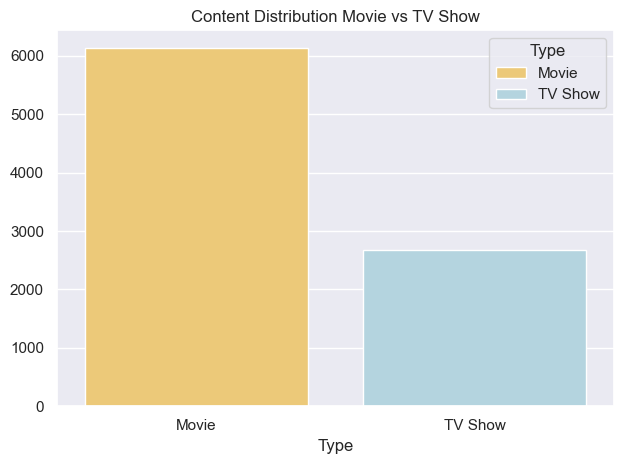

In [36]:
#Content Distribution
sns.countplot(
    data=new_netflix,
    x="Type",
    hue="Type",
    legend=True,
    palette={"Movie": "#FFD166", "TV Show": "lightblue"}
)

plt.title("Content Distribution Movie vs TV Show")
plt.xlabel("Type")
plt.ylabel("")
plt.tight_layout()